# Energy exposure map for Oregon

This notebook loads the main energy-related datasets in the repository and overlays them on a single Oregon-focused map using Cartopy.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Polygon

try:
    import h3
except ImportError:  # pragma: no cover
    h3 = None

def find_repo_root() -> Path:
    """Locate the repository root from the notebook working directory."""
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"

OREGON_BBOX = (-125.0, -116.0, 42.0, 46.5)
CRS_WGS84 = "EPSG:4326"
MAP_PROJECTION = ccrs.PlateCarree()


In [2]:
# Data center locations
DATA_CENTER_PATH = DATA_DIR / "data_centers_im3_pnnl" / "im3_open_source_data_center_atlas_v2026.02.09.csv"


def load_data_centers(path: Path) -> gpd.GeoDataFrame:
    df = pd.read_csv(path)
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs=CRS_WGS84,
    )


data_centers = load_data_centers(DATA_CENTER_PATH)
print("Data centers rows:", len(data_centers))
print(data_centers[["name", "lat", "lon"]].head(3).to_string(index=False))

Data centers rows: 1479
              name       lat        lon
           Verizon 40.544256 -74.496521
Google Data Center 35.894738 -81.546515
  Project Alluvion 41.515967 -93.711830


In [13]:
# Fiber density
FIBER_PATH = DATA_DIR / "fiber" / "bdc_41_FibertothePremises_fixed_broadband_D25_08jul2026.csv"


def load_fiber(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df["state_usps"] == "OR"].copy()
    df = df[df["max_advertised_download_speed"] >= 1000].copy()

    return df


def build_fiber_hexes(df: pd.DataFrame, resolution: int = 6) -> gpd.GeoDataFrame:
    density = (
        df.assign(
            h3_id=df["h3_res8_id"].apply(lambda x: h3.cell_to_parent(x, resolution))
        )
        .groupby("h3_id")
        .agg(
            location_count=("location_id", "count"),
            provider_count=("provider_id", "nunique"),
        )
        .reset_index()
    )

    density["geometry"] = density["h3_id"].apply(
        lambda h: None if pd.isna(h) else Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h)])
    )
    density = density.dropna(subset=["geometry"]).copy()

    return gpd.GeoDataFrame(density, geometry="geometry", crs=CRS_WGS84)


fiber_df = load_fiber(FIBER_PATH)
print("Fiber rows:", len(fiber_df))
print(fiber_df[["location_id", "provider_id", "state_usps", "h3_res8_id"]].head(3).to_string(index=False))

Fiber rows: 881559
 location_id  provider_id state_usps      h3_res8_id
  1117498795       131259         OR 8828f438cdfffff
  1117498815       131259         OR 8828f438cdfffff
  1305197156       131259         OR 8828f47089fffff


In [4]:
# Generators
GENERATOR_PATH = DATA_DIR / "EIA-generators" / "june_generator2026.xlsx"

def load_generators(path: Path) -> gpd.GeoDataFrame:
    excel_file = pd.ExcelFile(path)
    frames = []
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet_name)
        df.columns = df.iloc[1].fillna("").astype(str)
        df = df.iloc[2:].copy()
        df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
        df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    combined = combined.dropna(subset=["Latitude", "Longitude"]).copy()
    return gpd.GeoDataFrame(
        combined,
        geometry=gpd.points_from_xy(combined["Longitude"], combined["Latitude"]),
        crs=CRS_WGS84,
    )


try:
    generators = load_generators(GENERATOR_PATH)
    print("Generator rows:", len(generators))
    print(generators[["Latitude", "Longitude"]].head(3).to_string(index=False))
except Exception as exc:
    print("Generator layer unavailable:", exc)
    generators = None

Generator rows: 39659
 Latitude  Longitude
55.339722  -160.4972
55.339722  -160.4972
55.339722  -160.4972


In [5]:
# HIFLD infrastructure
SUBSTATIONS_PATH = DATA_DIR / "HIFLD" / "oregon_hifld_substations.gpkg"
TRANSMISSION_PATH = DATA_DIR / "HIFLD" / "oregon_hifld_transmission_lines.gpkg"

substations = gpd.read_file(SUBSTATIONS_PATH)
transmission = gpd.read_file(TRANSMISSION_PATH)

if substations.crs is not None:
    substations = substations.to_crs(CRS_WGS84)
if transmission.crs is not None:
    transmission = transmission.to_crs(CRS_WGS84)

print("Substations rows:", len(substations))
print("Transmission rows:", len(transmission))

Substations rows: 1412
Transmission rows: 2602


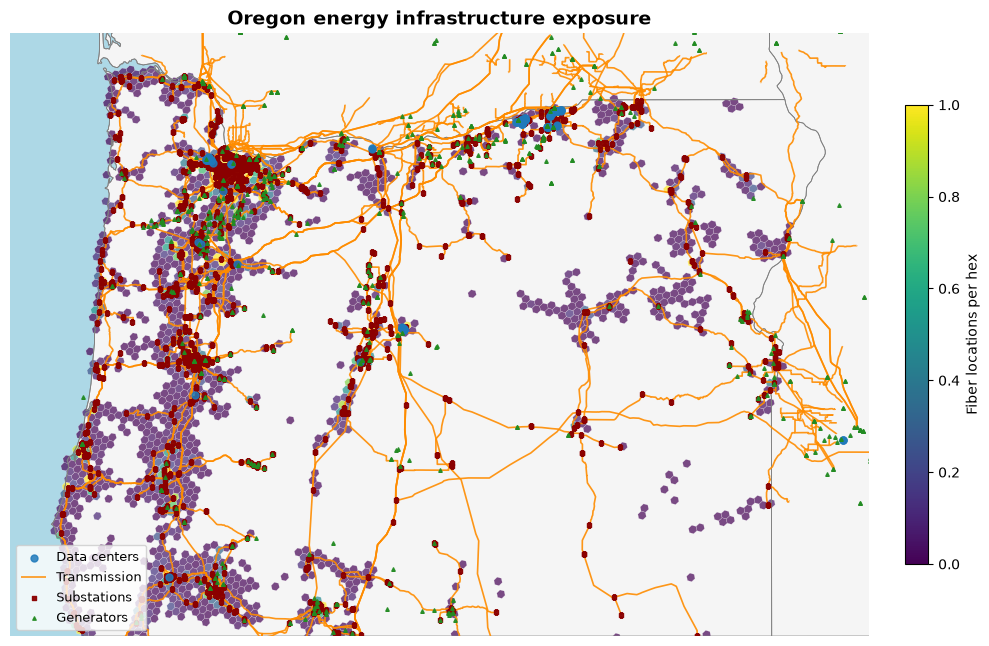

In [10]:
# Plot all available layers together for Oregon
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": MAP_PROJECTION})
ax.set_extent(OREGON_BBOX, crs=MAP_PROJECTION)

# Basemap styling
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", edgecolor="none")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", edgecolor="none")
ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor="gray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="gray")

# Plot layers
data_centers.plot(ax=ax, zorder=4, color="#1f7abb", marker="o", markersize=25, alpha=0.85, label="Data centers")

fiber_hexes = build_fiber_hexes(fiber_df, resolution=6)
plot = fiber_hexes.plot(ax=ax,zorder=1,column="location_count",cmap="viridis",edgecolor="white",linewidth=0.2,alpha=0.7,
                        vmin=1,vmax=max(10, fiber_hexes["location_count"].quantile(0.95)),legend=False,)

transmission.plot(ax=ax, zorder=2, color="darkorange", linewidth=1.2, alpha=0.9, label="Transmission")
substations.plot(ax=ax, zorder=3, color="darkred", marker="s", markersize=6, alpha=0.95, label="Substations")
generators.plot(ax=ax, zorder=5, color="forestgreen", marker="^", markersize=6, alpha=0.9, label="Generators")

mappable = plot.collections[0] if hasattr(plot, "collections") and plot.collections else None
if mappable is not None:
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.025, pad=0.04)
    cbar.set_label("Fiber locations per hex")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower left", frameon=True, fontsize=9)

ax.set_title("Oregon energy infrastructure exposure", fontsize=14, weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

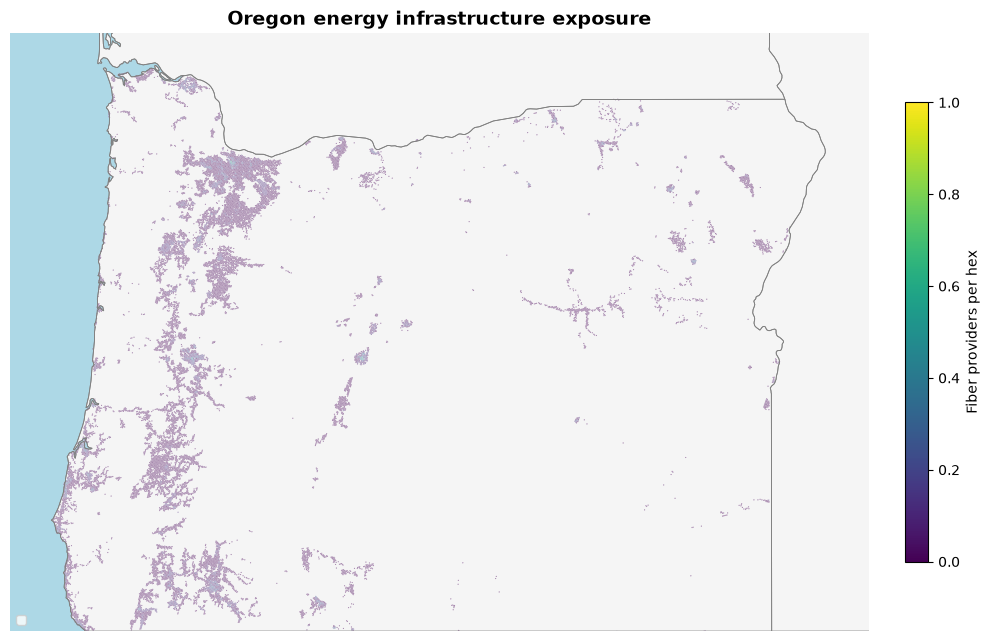

In [15]:
# Plot all available layers together for Oregon
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": MAP_PROJECTION})
ax.set_extent(OREGON_BBOX, crs=MAP_PROJECTION)

# Basemap styling
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", edgecolor="none")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", edgecolor="none")
ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor="gray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="gray")

fiber_hexes = build_fiber_hexes(fiber_df, resolution=8)
plot = fiber_hexes.plot(ax=ax,zorder=1,column="provider_count",cmap="viridis",edgecolor="white",linewidth=0.2,alpha=0.7,
                        vmin=1,vmax=max(10, fiber_hexes["provider_count"].quantile(0.95)),legend=False,)

mappable = plot.collections[0] if hasattr(plot, "collections") and plot.collections else None
if mappable is not None:
    cbar = fig.colorbar(mappable, ax=ax, fraction=0.025, pad=0.04)
    cbar.set_label("Fiber providers per hex")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="lower left", frameon=True, fontsize=9)

ax.set_title("Oregon energy infrastructure exposure", fontsize=14, weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [12]:
fiber_hexes

,h3_id,location_count,provider_count,geometry
0,8628122e7ffffff,31,1,"POLYGON ((-120.27325 41.93963, -120.23965 41.9..."
1,8628122efffffff,32,1,"POLYGON ((-120.32683 41.97951, -120.29323 42.0..."
2,86281306fffffff,1,1,"POLYGON ((-121.4177 42.05511, -121.38456 42.07..."
3,86281314fffffff,491,3,"POLYGON ((-121.38679 41.96018, -121.35366 41.9..."
4,862813217ffffff,75,1,"POLYGON ((-121.45685 42.30017, -121.42364 42.3..."
...,...,...,...,...
1460,8628f67a7ffffff,2,1,"POLYGON ((-120.99082 45.38267, -120.95627 45.4..."
1461,8628f67afffffff,9,1,"POLYGON ((-121.04652 45.42007, -121.01198 45.4..."
1462,8628f6a1fffffff,1,1,"POLYGON ((-121.85403 45.05531, -121.82 45.0789..."
1463,8628f6a47ffffff,1,1,"POLYGON ((-122.06712 45.05852, -122.03318 45.0..."


In [16]:
fiber_hexes

,h3_id,location_count,provider_count,geometry
0,8828122e33fffff,3,1,"POLYGON ((-120.29038 41.99424, -120.28558 41.9..."
1,8828122e3bfffff,28,1,"POLYGON ((-120.29375 41.98629, -120.28895 41.9..."
2,8828122ee5fffff,1,1,"POLYGON ((-120.29803 41.99993, -120.29323 42.0..."
3,8828122ee9fffff,6,1,"POLYGON ((-120.31243 41.98973, -120.30763 41.9..."
4,8828122eedfffff,25,1,"POLYGON ((-120.3014 41.99198, -120.2966 41.995..."
...,...,...,...,...
18608,8828f67ad7fffff,2,1,"POLYGON ((-121.07836 45.44142, -121.07343 45.4..."
18609,8828f6a1d7fffff,1,1,"POLYGON ((-121.88579 45.07651, -121.88093 45.0..."
18610,8828f6a429fffff,1,1,"POLYGON ((-122.05391 45.08937, -122.04906 45.0..."
18611,8828f6aa91fffff,1,1,"POLYGON ((-121.81155 45.10637, -121.80669 45.1..."
